# Explainable AI: COMPAS Predictions

Importing libraries

In [1]:
import pandas as pd

# for imputing modes and medians
from sklearn.impute import SimpleImputer

# for random forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import shap

# ! Assign target !

In [2]:
target = 'is_recid'

Importing data

In [3]:
# change file name for data if using different version
dfOriginal = pd.read_csv("cox-violent-parsed_filt.csv")

Remove duplicates, only one row per name

In [4]:
dfProcessed = dfOriginal.drop_duplicates(subset=['name'])
dfProcessed.count()

id                          6560
name                       10855
first                      10855
last                       10855
sex                        10855
dob                        10855
age                        10855
age_cat                    10855
race                       10855
juv_fel_count              10855
decile_score               10855
juv_misd_count             10855
juv_other_count            10855
priors_count               10855
days_b_screening_arrest     9781
c_jail_in                   9781
c_jail_out                  9781
c_days_from_compas         10185
c_charge_degree            10185
c_charge_desc              10178
is_recid                   10855
r_charge_degree             3425
r_days_from_arrest          2281
r_offense_date              3425
r_charge_desc               3368
r_jail_in                   2281
violent_recid                  0
is_violent_recid           10855
vr_charge_degree             809
vr_offense_date              809
vr_charge_

Remove unused columns

In [5]:
dfProcessed = dfProcessed[['sex', 'age', 'race', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count', 'c_charge_degree', target]]
dfProcessed.count()

sex                10855
age                10855
race               10855
juv_fel_count      10855
juv_misd_count     10855
juv_other_count    10855
priors_count       10855
c_charge_degree    10185
is_recid           10855
dtype: int64

Remove -1 is_recid (must be binary)

In [6]:
# What we expect to be dropped
# Just using this to double check
dfCheck = dfProcessed.loc[dfProcessed[target] < 0]
dfCheck.count()

sex                648
age                648
race               648
juv_fel_count      648
juv_misd_count     648
juv_other_count    648
priors_count       648
c_charge_degree      1
is_recid           648
dtype: int64

In [7]:
# Dropping the invalid is_recid values
dfProcessed = dfProcessed.loc[dfProcessed[target] > -1]
dfProcessed.count()

sex                10207
age                10207
race               10207
juv_fel_count      10207
juv_misd_count     10207
juv_other_count    10207
priors_count       10207
c_charge_degree    10184
is_recid           10207
dtype: int64

Missing value strategy
1. Numerical values --> MEDIAN imputation
2. Categorical values --> MODE imputation

In [8]:
print("Any NaN values?\n", dfProcessed.isnull().values.any())
# ^^ To check if any NaNs
# put it bc I tried a heatmap and it looked empty so double checking

Any NaN values?
 True


# DATA LEAKAGE 😰😰😰😰

In [9]:
# Numerical columns
numCols = ['age', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count']
numImputer = SimpleImputer(strategy = 'median')
dfProcessed[numCols] = numImputer.fit_transform(dfProcessed[numCols])

# Categorical columns
catCols = ['sex', 'race', 'c_charge_degree']
catImputer = SimpleImputer(strategy = 'most_frequent') # most_frequent = mode
dfProcessed[catCols] = catImputer.fit_transform(dfProcessed[catCols])

print("Any NaN values?\n", dfProcessed.isnull().values.any())
# no more NaNs :)

Any NaN values?
 False


Smote? Impute from other dataset? Impute from same dataset?

In [10]:
# We should discuss what the plan is for this part

Dummy Model
(idk if this is the right approach?)

In [11]:
# all target = 0

## Random Forest
!Note!

Random Forest requires all data to be in numbers, so the categorical data needs to be enumerated before we are able to use it. This is fine for our situation because the categorical data is not unique to each individual and can easily be turned into numbers.

In [12]:
X = dfProcessed.drop(target, axis=1)
y = dfProcessed[target]

testSize = 0.3 # change this variable if you want different train/test split
randNum = 44 # change if you want to adjust the random_state

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=testSize, random_state=randNum)

One-Hot Encoding

In [13]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output = False)
# handle_unknown prevents crash if it does not know the category
# puts 0 if it doesn't know it to indicate False
# sparse as False is important so it stores as a normal array

encoder.fit(X_train[catCols])

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [14]:
X_train_cat = encoder.transform(X_train[catCols])
X_test_cat = encoder.transform(X_test[catCols])

catNames = encoder.get_feature_names_out(catCols)

X_train_enc = pd.concat([
    X_train[numCols].reset_index(drop = True),
    pd.DataFrame(X_train_cat, columns = catNames)
], axis = 1)

X_test_enc = pd.concat([
    X_test[numCols].reset_index(drop = True),
    pd.DataFrame(X_test_cat, columns = catNames)
], axis = 1)

In [15]:
rf = RandomForestClassifier(n_estimators=300, random_state=randNum, min_samples_leaf=5, max_depth=10, class_weight='balanced')
rf.fit(X_train_enc, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
# What did the model predict?
predictions = rf.predict(X_test_enc)
predictions

array([0, 1, 0, ..., 1, 0, 0], dtype=int64)

In [17]:
# The probabilities it gave to each prediction
rf.predict_proba(X_test_enc)

array([[0.58389918, 0.41610082],
       [0.30555334, 0.69444666],
       [0.7245296 , 0.2754704 ],
       ...,
       [0.28861522, 0.71138478],
       [0.5003294 , 0.4996706 ],
       [0.76902093, 0.23097907]])

In [18]:
# Importance of each feature
importances = rf.feature_importances_
cols = X.columns

for i in range(len(cols)):
    print(f'Importance of {cols[i]} = {round(importances[i] * 100, 2)}%.')

# Note: the categorical features are split into
#   separate cols from using the dummy tool earlier.
# I kept them separate for now so we can see how
#   different races and charge degrees are treated.

Importance of sex = 28.46%.
Importance of age = 2.73%.
Importance of race = 4.44%.
Importance of juv_fel_count = 5.2%.
Importance of juv_misd_count = 39.02%.
Importance of juv_other_count = 2.12%.
Importance of priors_count = 2.49%.
Importance of c_charge_degree = 4.48%.


In [19]:
# Classification report returns precision, recall, F1, etc.
from sklearn.metrics import classification_report
print(classification_report(y_test, rf.predict(X_test_enc)))

              precision    recall  f1-score   support

           0       0.79      0.66      0.72      2047
           1       0.49      0.65      0.56      1016

    accuracy                           0.66      3063
   macro avg       0.64      0.66      0.64      3063
weighted avg       0.69      0.66      0.67      3063



# TreeSHAP

In [20]:
'''explainer = shap.TreeExplainer(rf)

shapValues = explainer.shap_values(X_test_enc)
'''

'explainer = shap.TreeExplainer(rf)\n\nshapValues = explainer.shap_values(X_test_enc)\n'

In [21]:
#shap.summary_plot(shapValues, X_test_enc)

In [22]:
# shap.plots.beeswarm(shapValues, max_display=99, show = False)

# ANCHORS

In [23]:
# anchors

# ANCHORS

Anchors provides highly precise, scoped "if-then" rules to explain individual predictions. This makes the model's logic easier to understand for non-technical experts like judges and legal practitioners.


In [24]:
#pip install alibi

In [ ]:
import numpy as np
import pandas as pd
import alibi #needs python 3.10
from alibi.explainers import AnchorTabular #needs python 3.10

Baseline anchor, using one-hot encoding

In [26]:
# extract feature names after one-hot encoding
feature_names = X_train_enc.columns.tolist()

# define the prediction function (a function that takes a numpy array and outputs class labels)
def predict_fn(x):
    # Convert the nameless numpy array back into a DataFrame with names
    df_x = pd.DataFrame(x, columns=feature_names)
    return rf.predict(x)

# convert datasets to numpy arrays, background data is used for sampling realistic perturbations
X_train_np = X_train_enc.to_numpy()
X_test_np  = X_test_enc.to_numpy()

explainer = AnchorTabular(predictor=predict_fn, feature_names=feature_names)

# fit the explainer to the background data, disc_perc argument discretizes continuous/numerical features into quartiles so Anchors can build logical rules.
explainer.fit(X_train_np, disc_perc=(25, 50, 75))

c:\Users\JD\miniconda3\envs\alibi_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


AnchorTabular(meta={
  'name': 'AnchorTabular',
  'type': ['blackbox'],
  'explanations': ['local'],
  'params': {'seed': None, 'disc_perc': (25, 50, 75)},
  'version': '0.9.6'}
)

In [27]:
# choose the test instance index you want to explain
i = 0
x = X_test_np[i]

# generate the explanation
explanation = explainer.explain(
    x,
    threshold=0.95  # we want an anchor rule with 95% precision
)

print("Prediction:", rf.predict(x.reshape(1, -1))[0])
print("\nAnchor rule:")
print(" AND ".join(explanation.anchor))

print("\nPrecision:", explanation.precision)
print("Coverage:", explanation.coverage)

c:\Users\JD\miniconda3\envs\alibi_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\JD\miniconda3\envs\alibi_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\JD\miniconda3\envs\alibi_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\JD\miniconda3\envs\alibi_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\JD\miniconda3\envs\alibi_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but 

Prediction: 0

Anchor rule:
priors_count <= 1.00 AND race_African-American <= 0.00 AND juv_other_count <= 0.00 AND c_charge_degree_(F3) <= 0.00

Precision: 0.9534313725490197
Coverage: 0.1495


Anchor: using a wrapper for the encoder to no longer use 1/0's but to use original feature namings

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
from alibi.explainers import AnchorTabular

from sklearn.preprocessing import OrdinalEncoder

# create an ordinal encoder specifically to translate strings to integers for Alibi
ordinal_enc = OrdinalEncoder()

# fit on the entire dataset's categorical columns (X) so it learns every possible category
ordinal_enc.fit(X[catCols])

X_train_alibi = X_train.copy()
X_test_alibi = X_test.copy()

# convert categorical string columns into integers using the fully informed encoder
X_train_alibi[catCols] = ordinal_enc.transform(X_train[catCols])
X_test_alibi[catCols] = ordinal_enc.transform(X_test[catCols])

# Get the numerical column index for each categorical feature
cat_indices = [X_train.columns.get_loc(col) for col in catCols]

# tell Alibi which columns are categorical and give it the dictionary of names
categorical_names = {}
for i, col_name in enumerate(catCols):
    col_idx = cat_indices[i]
    # map the column index to the list of category names (caucasian, african-american, etc)
    categorical_names[col_idx] = ordinal_enc.categories_[i].tolist()

# wrapper function to avoid using one-hot-encoding and instead use the feature names provided
raw_feature_names = X_train.columns.tolist()

def predict_fn_wrapped(x):
    # x comes in as a float32 numpy array from Alibi
    df_x = pd.DataFrame(x, columns=raw_feature_names)
    
    # inverse transform the integers back to original strings (0 = male, 1 = female)
    df_x[catCols] = ordinal_enc.inverse_transform(df_x[catCols])
    
    # apply existing OneHotEncoder
    encoded_cats = encoder.transform(df_x[catCols])
    df_encoded_cats = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(catCols))
    
    # recombine numerical and newly encoded categorical columns
    df_final = pd.concat([
        df_x[numCols].reset_index(drop=True), 
        df_encoded_cats
    ], axis=1)
    
    # pass the formatted data to the Random Forest
    return rf.predict(df_final)

# initialize AnchorTabular with the categorical dictionary
explainer = AnchorTabular(
    predictor=predict_fn_wrapped, 
    feature_names=raw_feature_names,
    categorical_names=categorical_names
)

# fit the explainer using the fully numerical Alibi dataset
explainer.fit(X_train_alibi.to_numpy(), disc_perc=(25, 50, 75))

AnchorTabular(meta={
  'name': 'AnchorTabular',
  'type': ['blackbox'],
  'explanations': ['local'],
  'params': {'seed': None, 'disc_perc': (25, 50, 75)},
  'version': '0.9.6'}
)

In [29]:
# choose the test instance index you want to explain
i = 1  
x = X_test_alibi.to_numpy()[i]

explanation = explainer.explain(
    x,
    threshold=0.95 
)

print("Prediction:", predict_fn_wrapped(x.reshape(1, -1))[0])
print("\nAnchor rule:")
print(" AND ".join(explanation.anchor))

print("\nPrecision:", explanation.precision)
print("Coverage:", explanation.coverage)

Prediction: 1

Anchor rule:
priors_count > 4.00 AND age <= 26.00

Precision: 1.0
Coverage: 0.0362


Search for a specific profile, check for bias with specific features/variables

In [30]:
# finding an African-American defendant who the model predicts WILL reoffend
target_index = None

# enumerate to get a positional index alongside the row data
for pos_idx, (pandas_idx, row) in enumerate(X_test.iterrows()):
    
    # check the original unencoded data for the race
    if row['race'] == 'African-American':
        
        # use the pos_idx for the encoded dataset
        if rf.predict(X_test_enc.iloc[[pos_idx]])[0] == 1:
            target_index = pos_idx  # save the positional index
            break

if target_index is not None:
    print(f"Explaining instance at positional index: {target_index}")
    
    # x_target takes the positional index from the numpy array
    x_target = X_test_alibi.to_numpy()[target_index]
    
    explanation = explainer.explain(x_target, threshold=0.95)
    
    print("Prediction:", predict_fn_wrapped(x_target.reshape(1, -1))[0])
    print("Anchor rule:", " AND ".join(explanation.anchor))

Explaining instance at positional index: 5
Prediction: 1
Anchor rule: priors_count > 4.00 AND juv_other_count > 0.00


Calculating Fidelity

Alibi  calculates a form of this automatically: the explanation.precision metric is the fidelity of the rule on the simulated/perturbed data.

Empirical Fidelity: applying the Anchor rule to the actual historical test data to see if the model actually obeys the rule in the dataset.

Empirical Fidelity Function
Once Anchors give a rule, we need to verify it.

mask_array = rule_conditions.to_numpy(): convert the pandas boolean mask into a raw numpy array. This strips away the mismatched row labels (like row 8699), and allows us to filter purely by row position.

1. Finding matches: total_matches = mask_array.sum() counts exactly how many people in the entire test set fit the "if-then" criteria of the anchor rule.

2. Getting predictions: we isolate those specific individuals in the encoded dataset (encoded_matches) and feed them all to the Random Forest (rf.predict(encoded_matches)).

3. Calculating the metric: compare the model's actual predictions against what the Anchor rule promised the prediction would be (original_prediction). We calculate fidelity using a simple ratio:

Fidelity = "Correct Predictions / Total Matches"

A high fidelity value indicates that the explanation captures sufficient information to truly explain the model's underlying logic.



In [31]:
def calculate_empirical_fidelity(rule_conditions, original_prediction, X_test_df, X_test_encoded):
    # strip the mismatched pandas index by converting the mask to a raw numpy array
    mask_array = rule_conditions.to_numpy()
    
    # 1. find all people in the test set who match the anchor rule
    total_matches = mask_array.sum()
    
    if total_matches == 0:
        return "No matches in test set (Coverage is 0%)"
        
    # 2. get the model's predictions for all of these matching people. we apply the pure positional numpy mask directly to the encoded data
    encoded_matches = X_test_encoded[mask_array]
    predictions = rf.predict(encoded_matches)
    
    # 3. count how many times the model's prediction matches the anchor's prediction
    correct_predictions = sum(predictions == original_prediction)
    
    # 4. calculate Fidelity = the percentage of time the model obeyed the rule
    fidelity = correct_predictions / total_matches
    
    print(f"The rule applied to {total_matches} individuals in the test set.")
    print(f"The model predicted {original_prediction} for {correct_predictions} of them.")
    print(f"Empirical Fidelity: {round(fidelity * 100, 2)}%")
    return fidelity

# use/test it here: create a boolean mask matching those exact conditions on your raw test dataframe
example_custom_rule_mask = (X_test['priors_count'] <= 1.0) & (X_test['race'] == 'Hispanic')

calculate_empirical_fidelity(
    rule_conditions=example_custom_rule_mask, 
    original_prediction=0, 
    X_test_df=X_test, 
    X_test_encoded=X_test_enc
)

The rule applied to 181 individuals in the test set.
The model predicted 0 for 172 of them.
Empirical Fidelity: 95.03%


0.9502762430939227

Could not find an anchor satisfying the 0.95 precision constraint. Now returning the best non-eligible result. The desired precision threshold might not be achieved due to the quantile-based discretisation of the numerical features. The resolution of the bins may be too large to find an anchor of required precision. Consider increasing the number of bins in `disc_perc`, but note that for some numerical distribution (e.g. skewed distribution) it may not help.
Could not find an anchor satisfying the 0.95 precision constraint. Now returning the best non-eligible result. The desired precision threshold might not be achieved due to the quantile-based discretisation of the numerical features. The resolution of the bins may be too large to find an anchor of required precision. Consider increasing the number of bins in `disc_perc`, but note that for some numerical distribution (e.g. skewed distribution) it may not help.
Could not find an anchor satisfying the 0.95 precision constraint. Now ret

Reached sample limit for all groups. Stopping early.

   TOP RULES: PREDICTED TO REOFFEND    


,Group,Rank,Rule,Prediction,Coverage,Precision (Fidelity)
0,Caucasian,1,priors_count > 1.00 AND age <= 32.00,Reoffend,0.2338,0.952532
1,Caucasian,2,priors_count > 1.00 AND age <= 32.00 AND sex =...,Reoffend,0.2006,0.973684
2,Caucasian,3,priors_count > 1.00 AND sex = Male AND c_charg...,Reoffend,0.2387,0.770955
3,African-American,1,priors_count > 4.00,Reoffend,0.2406,0.966942
4,African-American,2,priors_count > 1.00 AND age <= 32.00 AND sex =...,Reoffend,0.1973,0.973585
5,African-American,3,priors_count > 4.00 AND age <= 43.00,Reoffend,0.1699,0.980645
6,Female,1,priors_count > 1.00 AND age <= 32.00,Reoffend,0.2420,0.970588
7,Female,2,priors_count > 4.00 AND age <= 43.00,Reoffend,0.1685,0.970954
8,Female,3,priors_count > 1.00 AND age <= 32.00 AND race ...,Reoffend,0.1595,0.951673
9,Male,1,priors_count > 1.00 AND age <= 32.00,Reoffend,0.2357,0.966102



    TOP RULES: PREDICTED TO NOT REOFFEND    


,Group,Rank,Rule,Prediction,Coverage,Precision (Fidelity)
0,Caucasian,1,priors_count <= 1.00 AND age > 26.00,No Reoffend,0.3331,0.970667
1,Caucasian,2,priors_count <= 1.00 AND age > 32.00,No Reoffend,0.2300,0.983471
2,Caucasian,3,priors_count <= 0.00 AND age > 26.00,No Reoffend,0.2094,0.969758
3,African-American,1,age > 32.00 AND priors_count <= 4.00 AND juv_o...,No Reoffend,0.3502,0.950966
4,African-American,2,age > 32.00 AND priors_count <= 4.00 AND juv_o...,No Reoffend,0.3466,0.952320
5,African-American,3,age > 32.00 AND priors_count <= 4.00 AND juv_o...,No Reoffend,0.3414,0.946996
6,Female,1,priors_count <= 1.00 AND age > 32.00,No Reoffend,0.2347,0.992188
7,Female,2,age > 43.00 AND priors_count <= 4.00,No Reoffend,0.1850,0.960171
8,Female,3,priors_count <= 0.00 AND age > 32.00,No Reoffend,0.1438,0.990000
9,Male,1,age > 32.00 AND priors_count <= 4.00 AND juv_o...,No Reoffend,0.3422,0.963710


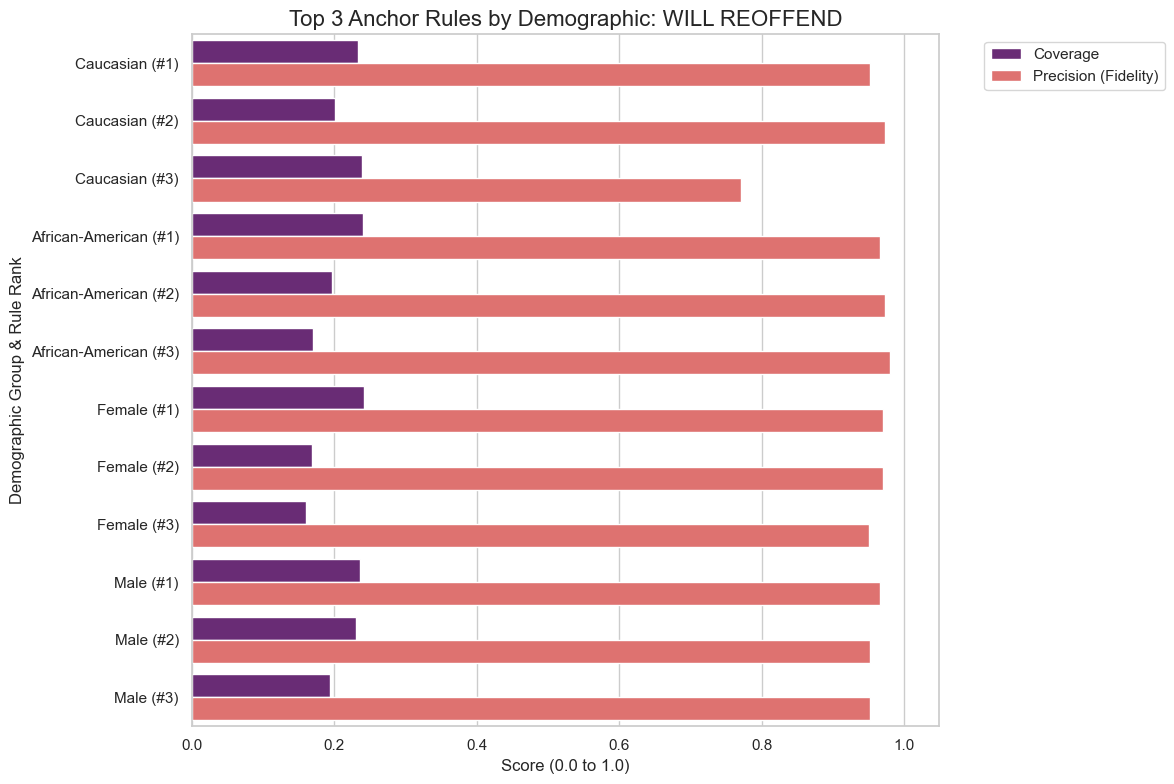

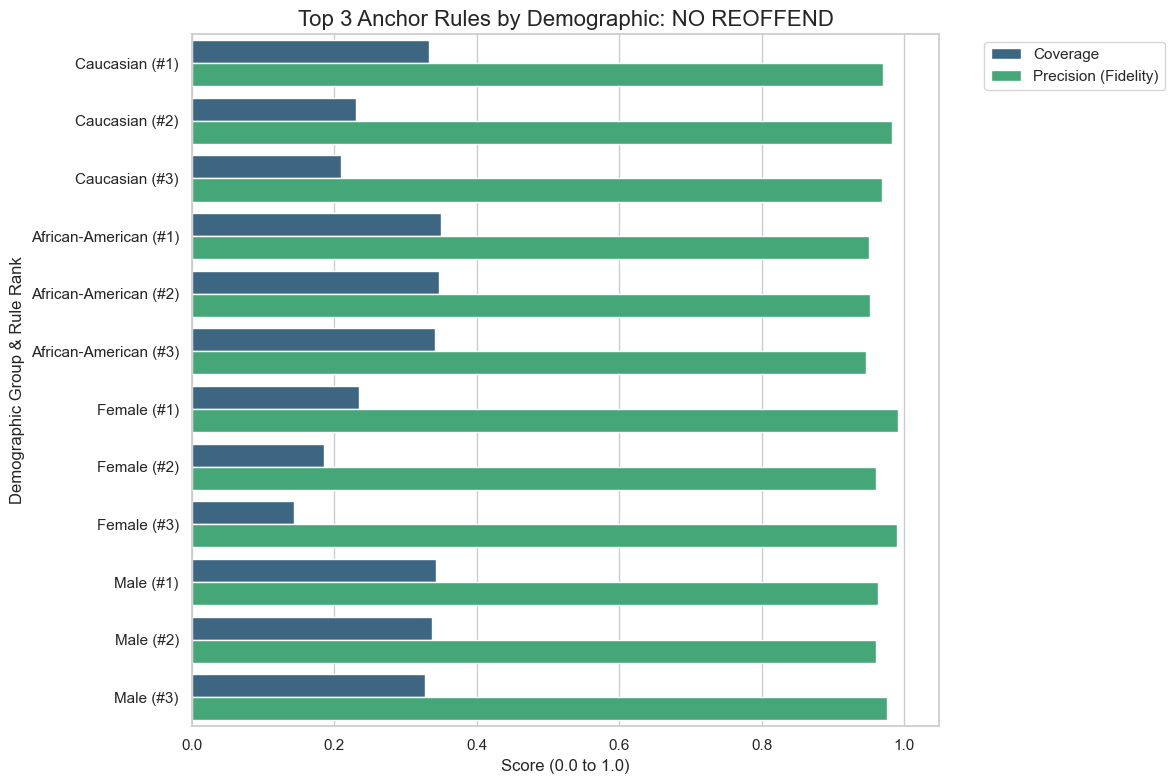


    RULE SUMMARY    
Total Reference Population (Test Set Size): 3063 individuals

    REOFFEND RULES    
[Caucasian Rule #1] (Predicts Reoffend):
Rule: priors_count > 1.00 AND age <= 32.00
Applies to ~716 people (Coverage: 23.4%).
The model predicts 'Reoffend' for ~682 of them (Precision: 95.3%).

[Caucasian Rule #2] (Predicts Reoffend):
Rule: priors_count > 1.00 AND age <= 32.00 AND sex = Male
Applies to ~614 people (Coverage: 20.1%).
The model predicts 'Reoffend' for ~598 of them (Precision: 97.4%).

[Caucasian Rule #3] (Predicts Reoffend):
Rule: priors_count > 1.00 AND sex = Male AND c_charge_degree = (F3)
Applies to ~731 people (Coverage: 23.9%).
The model predicts 'Reoffend' for ~564 of them (Precision: 77.1%).

[African-American Rule #1] (Predicts Reoffend):
Rule: priors_count > 4.00
Applies to ~737 people (Coverage: 24.1%).
The model predicts 'Reoffend' for ~713 of them (Precision: 96.7%).

[African-American Rule #2] (Predicts Reoffend):
Rule: priors_count > 1.00 AND age <= 32

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. define groups and setup storage for both prediction outcomes
target_groups = {
    'Caucasian': {'condition': lambda r: r['race'] == 'Caucasian', 'rules_0': {}, 'rules_1': {}},
    'African-American': {'condition': lambda r: r['race'] == 'African-American', 'rules_0': {}, 'rules_1': {}},
    'Female': {'condition': lambda r: r['sex'] == 'Female', 'rules_0': {}, 'rules_1': {}},
    'Male': {'condition': lambda r: r['sex'] == 'Male', 'rules_0': {}, 'rules_1': {}}
}

# 2. increase the limit to ensure we find enough of both classes per group
MAX_INSTANCES_PER_GROUP = 100 
processed_counts = {k: 0 for k in target_groups.keys()}


# 3. loop through test instances
for pos_idx, (pandas_idx, row) in enumerate(X_test.iterrows()):
    
    # stop early if we have enough total samples for all groups
    if all(count >= MAX_INSTANCES_PER_GROUP for count in processed_counts.values()):
        print("Reached sample limit for all groups. Stopping early.")
        break
        
    x_target = X_test_alibi.to_numpy()[pos_idx]
    prediction = predict_fn_wrapped(x_target.reshape(1, -1))[0]
    
    # route the rule to the correct dictionary based on the prediction (0 or 1)
    dict_key = 'rules_1' if prediction == 1 else 'rules_0'
    
    # check which groups this instance belongs to
    for group_name, group_data in target_groups.items():
        if group_data['condition'](row) and processed_counts[group_name] < MAX_INSTANCES_PER_GROUP:
            
            # generate explanation
            explanation = explainer.explain(x_target, threshold=0.95)
            
            # extract metrics
            rule_text = " AND ".join(explanation.anchor)
            precision = explanation.precision
            coverage = explanation.coverage
            
            # store rule: deduplicate by using rule_text as the key
            if rule_text not in group_data[dict_key]:
                group_data[dict_key][rule_text] = {
                    'coverage': coverage,
                    'precision': precision,
                    'prediction': prediction,
                    'utility_score': coverage * precision
                }
            
            processed_counts[group_name] += 1

# 4. extract top 3 rules per group for both outcomes
def extract_top_rules(prediction_key, prediction_label):
    summary = []
    for group_name, group_data in target_groups.items():
        # sort rules by utility score in descending order
        sorted_rules = sorted(group_data[prediction_key].items(), key=lambda x: x[1]['utility_score'], reverse=True)
        
        # grab the Top 3
        for rank, (rule_text, metrics) in enumerate(sorted_rules[:3]):
            summary.append({
                'Group': group_name,
                'Rank': rank + 1,
                'Rule': rule_text,
                'Prediction': prediction_label,
                'Coverage': metrics['coverage'],
                'Precision (Fidelity)': metrics['precision']
            })
    return pd.DataFrame(summary)

df_reoffend = extract_top_rules('rules_1', 'Reoffend')
df_no_reoffend = extract_top_rules('rules_0', 'No Reoffend')

# display tables
print("\n   TOP RULES: PREDICTED TO REOFFEND    ")
display(df_reoffend)

print("\n    TOP RULES: PREDICTED TO NOT REOFFEND    ")
display(df_no_reoffend)

# 5. visualization function
def plot_top_rules(df, title, palette):
    if df.empty:
        return
        
    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid")
    
    df['Display_Label'] = df['Group'] + " (#" + df['Rank'].astype(str) + ")"
    df_melted = df.melt(id_vars=['Display_Label', 'Group'], 
                        value_vars=['Coverage', 'Precision (Fidelity)'], 
                        var_name='Metric', value_name='Score')
    
    sns.barplot(x='Score', y='Display_Label', hue='Metric', data=df_melted, palette=palette)
    plt.title(title, fontsize=16)
    plt.xlabel('Score (0.0 to 1.0)', fontsize=12)
    plt.ylabel('Demographic Group & Rule Rank', fontsize=12)
    plt.xlim(0, 1.05)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# generate graphs
plot_top_rules(df_reoffend, 'Top 3 Anchor Rules by Demographic: WILL REOFFEND', 'magma')
plot_top_rules(df_no_reoffend, 'Top 3 Anchor Rules by Demographic: NO REOFFEND', 'viridis')

# 6. summary
print("\n    RULE SUMMARY    ")
test_set_size = len(X_test)
print(f"Total Reference Population (Test Set Size): {test_set_size} individuals\n")

def print_human_summary(df, prediction_label):
    if df.empty:
        return
    for _, row in df.iterrows():
        # calculate exactly how many people this affects
        total_matches = int(round(row['Coverage'] * test_set_size))
        correct_preds = int(round(row['Precision (Fidelity)'] * total_matches))
        
        print(f"[{row['Group']} Rule #{row['Rank']}] (Predicts {prediction_label}):")
        print(f"Rule: {row['Rule']}")
        print(f"Applies to ~{total_matches} people (Coverage: {row['Coverage']*100:.1f}%).")
        print(f"The model predicts '{prediction_label}' for ~{correct_preds} of them (Precision: {row['Precision (Fidelity)']*100:.1f}%).\n")

print("    REOFFEND RULES    ")
print_human_summary(df_reoffend, 'Reoffend')

print("    NO REOFFEND RULES    ")
print_human_summary(df_no_reoffend, 'No Reoffend')